# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

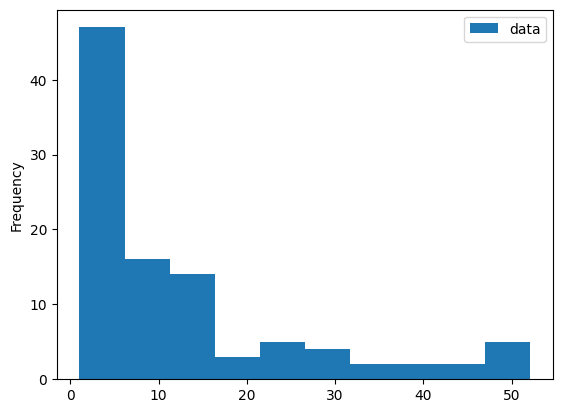

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

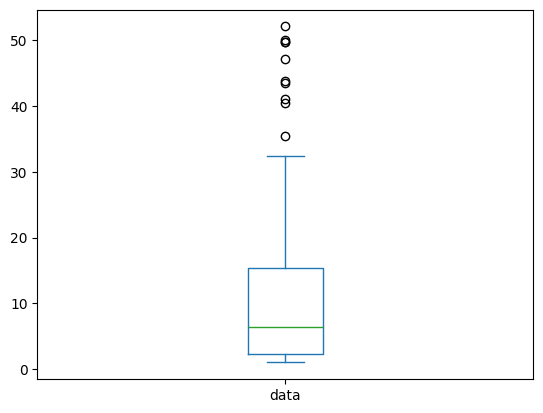

In [3]:
df.plot.box()

First thing i notice is that neither of the graphs have labels to indicate what we're looking at. A stakeholder, nor someone who has not done this themselves would not be able to iterprate what is going on in the graphs.The visual is fine imo, just needs some labels and preferably outline for the histogram to be more clearly understood.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")

print(path)
print(os.listdir(path))
import pandas as pd
import os

df_m = pd.read_csv(os.path.join(path, "digital_marketing_campaign_dataset.csv"))
df_m.head()



/home/codespace/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1
['digital_marketing_campaign_dataset.csv']


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [6]:
numeric_cols = df_m.select_dtypes(include=['int64','float64']).columns
categorical_cols = df_m.select_dtypes(include=['object']).columns

/tmp/ipykernel_50444/1528166017.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_m.select_dtypes(include=['object']).columns


In [7]:
df_m.isna().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [8]:
mean=df_m[numeric_cols].mean()
median= df_m[numeric_cols].median()
mode= df_m[numeric_cols].mode()
print("Mean:\n", mean)
print("Median:\n", median)
print("Mode:\n", mode)

Mean:
 CustomerID           11999.500000
Age                     43.625500
Income               84664.196750
AdSpend               5000.944830
ClickThroughRate         0.154829
ConversionRate           0.104389
WebsiteVisits           24.751625
PagesPerVisit            5.549299
TimeOnSite               7.727718
SocialShares            49.799750
EmailOpens               9.476875
EmailClicks              4.467375
PreviousPurchases        4.485500
LoyaltyPoints         2490.268500
Conversion               0.876500
dtype: float64
Median:
 CustomerID           11999.500000
Age                     43.000000
Income               84926.500000
AdSpend               5013.440044
ClickThroughRate         0.154505
ConversionRate           0.104046
WebsiteVisits           25.000000
PagesPerVisit            5.534257
TimeOnSite               7.682956
SocialShares            50.000000
EmailOpens               9.000000
EmailClicks              4.000000
PreviousPurchases        4.000000
LoyaltyPoints    

In [9]:
df_m.groupby("Conversion")[numeric_cols].mean()


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
Conversion,,,,,,,,,,,,,,,
0,13111.489879,43.561741,83265.308704,4058.398466,0.127972,0.090766,21.726721,4.835002,6.267871,50.681174,7.576923,3.481781,3.625506,2128.483806,0.0
1,11842.819167,43.634484,84861.301911,5133.750850,0.158613,0.106308,25.177838,5.649945,7.933413,49.675556,9.744581,4.606246,4.606674,2541.244438,1.0


All data points are clean, no NA's and no odd reaches from data. 

<Axes: xlabel='CampaignChannel'>

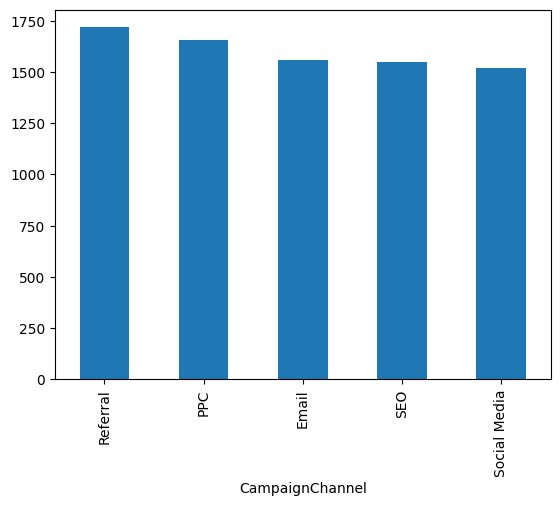

In [10]:
df_m["CampaignChannel"].value_counts().plot(kind="bar")


Fairly uniformal variables, it does not seem like it is a normally distributed dataset where sudden spikes or a lot of outliers are expected.

<Axes: xlabel='AdSpend', ylabel='Count'>

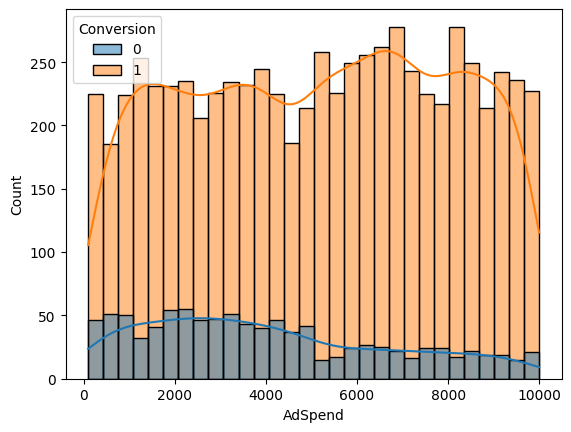

In [11]:
sns.histplot(data=df_m, x="AdSpend", hue="Conversion", bins=30, kde=True)

<Axes: xlabel='ClickThroughRate', ylabel='Count'>

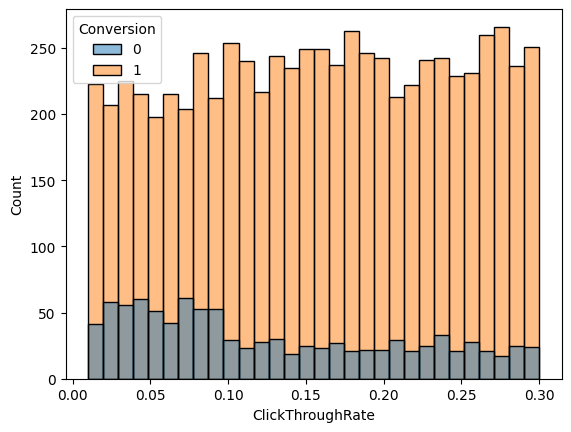

In [12]:
sns.histplot(data=df_m, x="ClickThroughRate", hue="Conversion", bins=30)

<Axes: xlabel='Income', ylabel='Count'>

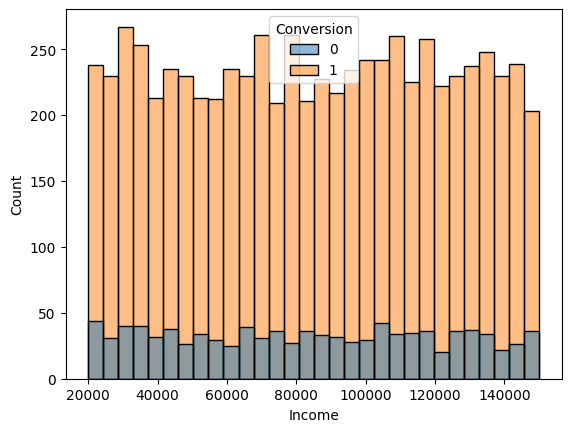

In [13]:

sns.histplot(data=df_m, x="Income", hue="Conversion", bins=30)

<Axes: xlabel='TimeOnSite', ylabel='Count'>

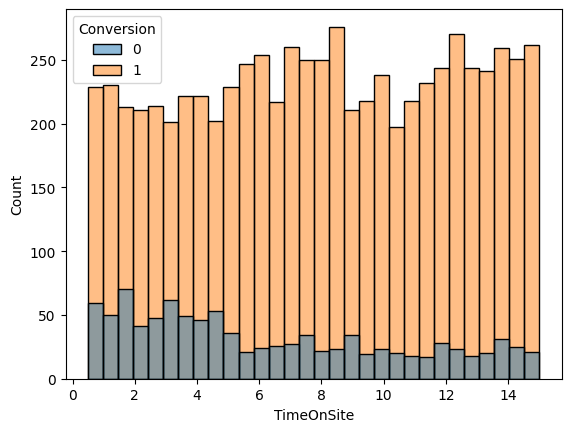

In [14]:
sns.histplot(data=df_m, x="TimeOnSite", hue="Conversion", bins=30)


No substantial skewness, bimodality, or extreme outliers are visually apparent, suggesting that the variables are well bounded and internally consistent. When comparing grouped histograms by Conversion outcome, clear distributional shifts emerge, converted users tend to display higher AdSpend, higher ClickThroughRate, and longer TimeOnSite values. These differences align with expected marketing behavior with increased engagement and investment are associated with greater conversion likelihood.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

So I did a Gestalt principle of closure, that is supposed to show us not exactly the data points and an exact relationship; but for the brain to be able to comprehend the overall pciture of how they relate within the weight of the colors on how Ad spending can effect on the success of conversion patterns.

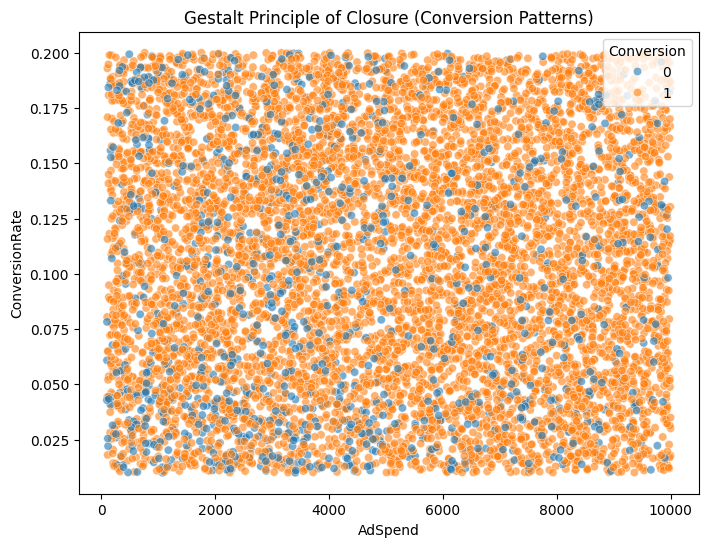

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_m,
    x="AdSpend",
    y="ConversionRate",
    hue="Conversion", 
    alpha=0.6
)

plt.title("Gestalt Principle of Closure (Conversion Patterns)")
plt.show()